# hERG bioactivity from ChEMBL

The chembl_websource_client library helps accessing ChEMBL data and cheminformatics tools from Python. You don't need to know how to write SQL. You don't need to know how to interact with REST APIs. You don't need to compile or install any cheminformatics frameworks.  This notebook pulls hERG (KCNH2, **CHEMBL240**) IC50 data from ChEMBL with the official
[`chembl_webresource_client`](https://github.com/chembl/chembl_webresource_client),
restricted to **exact IC50 values in nM** (`standard_relation = '='`, no potency cutoff), then cleans,
aggregates and explores it with pandas and RDKit.

## Setup

In [5]:
from chembl_webresource_client.settings import Settings

# The client defaults to 20 rows per request and a 3 s timeout, which makes a
# ~10k-row pull take minutes. The API allows 1000 rows per page.
Settings.Instance().MAX_LIMIT = 1000
Settings.Instance().TIMEOUT = 60

from chembl_webresource_client.new_client import new_client

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Draw

RDLogger.DisableLog("rdApp.*")
pd.set_option("display.max_colwidth", 80)

In [6]:
#You can list all resources

available_resources = [resource for resource in dir(new_client) if not resource.startswith('_')]
print(available_resources)

['activity', 'activity_supplementary_data_by_activity', 'assay', 'assay_class', 'atc_class', 'binding_site', 'biotherapeutic', 'cell_line', 'chembl_id_lookup', 'chembl_release', 'compound_record', 'compound_structural_alert', 'description', 'document', 'document_similarity', 'drug', 'drug_indication', 'drug_warning', 'go_slim', 'image', 'mechanism', 'metabolism', 'molecule', 'molecule_form', 'official', 'organism', 'protein_classification', 'similarity', 'source', 'substructure', 'target', 'target_component', 'target_relation', 'tissue', 'xref_source']


The design of the client is based on Django QuerySet (https://docs.djangoproject.com/en/1.11/ref/models/querysets) and most important lookup types are supported. These are: exact, iexact, contains, icontains, in, gt, gte, lt, lte, startswith, istartswith, endswith, iendswith, range, isnull, regex, iregex, search

## Find the hERG target and CHEMBL_ID

In [8]:
target = new_client.target
activity = new_client.activity

herg = target.filter(pref_name__iexact='Voltage-gated inwardly rectifying potassium channel KCNH2').only('target_chembl_id')[0]
herg

{'target_chembl_id': 'CHEMBL240'}

## Query hERG IC50 activities (exact values, no potency cutoff)

Filters are applied server-side. `.only()` trims each record to the fields we need,
which keeps the download small. Results are cached locally by the client (24 h), so
re-running is fast.

In [9]:
IC50_CUTOFF_NM = None    # e.g. 10000 to keep only IC50 < 10 µM; None = no cutoff

fields = [
    "activity_id", "molecule_chembl_id", "molecule_pref_name", "canonical_smiles",
    "standard_type", "standard_relation", "standard_value", "standard_units",
    "pchembl_value", "assay_chembl_id", "assay_type", "assay_description",
    "document_chembl_id", "document_year", "data_validity_comment",
]

query = dict(
    target_chembl_id=herg["target_chembl_id"],
    standard_type="IC50",
    standard_units="nM",
    standard_relation="=",       # exact measurements only; excludes '>' / '<' bounds
)
if IC50_CUTOFF_NM is not None:
    query["standard_value__lt"] = IC50_CUTOFF_NM

herg_acts = activity.filter(**query).only(fields)

print(f"{len(herg_acts):,} activity records")

12,010 activity records


In [10]:
df = pd.DataFrame.from_records(herg_acts)
for col in ("standard_value", "pchembl_value"):
    df[col] = pd.to_numeric(df[col], errors="coerce")
df.head()

,activity_id,assay_chembl_id,assay_description,assay_type,canonical_smiles,data_validity_comment,document_chembl_id,document_year,molecule_chembl_id,molecule_pref_name,pchembl_value,relation,standard_relation,standard_type,standard_units,standard_value,type,units,value
0,305156,CHEMBL841079,Inhibition of hERG currents Kv11.1,T,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc23)CC1,NaN,CHEMBL1134478,2001.0,CHEMBL12713,SERTINDOLE,7.85,=,=,IC50,nM,14.0,IC50,nM,14.0
1,305156,CHEMBL841079,Inhibition of hERG currents Kv11.1,T,O=C1NCCN1CCN1CCC(c2cn(-c3ccc(F)cc3)c3ccc(Cl)cc23)CC1,NaN,CHEMBL1134478,2001.0,CHEMBL12713,SERTINDOLE,7.85,=,=,IC50,nM,14.0,IC50,nM,14.0
2,305244,CHEMBL691014,K+ channel blocking activity in human embryonic kidney cells expressing HERG...,F,O=C(CCCN1CC=C(n2c(=O)[nH]c3ccccc32)CC1)c1ccc(F)cc1,NaN,CHEMBL1135758,2002.0,CHEMBL1108,DROPERIDOL,7.49,=,=,IC50,nM,32.2,IC50,nM,32.2
3,305245,CHEMBL691013,K+ channel blocking activity in human embryonic kidney cells expressing HERG...,F,O=C(O[C@@H]1C[C@@H]2C[C@H]3C[C@H](C1)N2CC3=O)c1c[nH]c2ccccc12,NaN,CHEMBL1135758,2002.0,CHEMBL2368925,DOLASETRON,5.22,=,=,IC50,nM,5950.0,IC50,nM,5950.0
4,306561,CHEMBL691014,K+ channel blocking activity in human embryonic kidney cells expressing HERG...,F,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C)cc1OC,NaN,CHEMBL1135758,2002.0,CHEMBL6966,VERAPAMIL,6.84,=,=,IC50,nM,143.0,IC50,nM,143.0


## What came back

In [11]:
print("Relations:\n", df["standard_relation"].value_counts(dropna=False), "\n")
print("Assay types (B=binding, F=functional, A=ADMET, T=toxicity):\n", df["assay_type"].value_counts(), "\n")
print("Validity flags:\n", df["data_validity_comment"].value_counts(dropna=False))

Relations:
 standard_relation
=    12011
Name: count, dtype: int64 

Assay types (B=binding, F=functional, A=ADMET, T=toxicity):
 assay_type
B    10219
T     1544
F      217
A       31
Name: count, dtype: int64 

Validity flags:
 data_validity_comment
NaN                              11710
Outside typical range              293
Potential transcription error        8
Name: count, dtype: int64


## Clean and aggregate

- keep exact measurements (`=`) — a `<` value only bounds the IC50;
- drop records ChEMBL flags as questionable (`data_validity_comment`) or with no structure;
  ChEMBL flags every IC50 > 100 µM as *Outside typical range*, so pIC50 has a floor of 4;
- compute pIC50 = 9 − log10(IC50 nM) and take the **median per compound** across assays.

In [12]:
clean = df[
    (df["standard_relation"] == "=")
    & df["data_validity_comment"].isna()
    & df["canonical_smiles"].notna()
    & (df["standard_value"] > 0)
].copy()
clean["pIC50"] = 9 - np.log10(clean["standard_value"])

per_cpd = (
    clean.groupby("molecule_chembl_id")
    .agg(
        smiles=("canonical_smiles", "first"),
        name=("molecule_pref_name", "first"),
        pIC50=("pIC50", "median"),
        pIC50_sd=("pIC50", "std"),
        n=("pIC50", "size"),
        first_year=("document_year", "min"),
    )
    .reset_index()
    .sort_values("pIC50", ascending=False)
)
per_cpd["IC50_nM"] = 10 ** (9 - per_cpd["pIC50"])
print(f"{len(df):,} records -> {len(clean):,} clean -> {len(per_cpd):,} unique compounds")
per_cpd.head(10)

12,011 records -> 11,708 clean -> 9,628 unique compounds


,molecule_chembl_id,smiles,name,pIC50,pIC50_sd,n,first_year,IC50_nM
5958,CHEMBL4595328,O=C(N[C@H]1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[C@@]2(CCN3CC2CC2)[C@H]1O5)c1cccc2c...,NaN,10.677781,NaN,1,2023.0,0.021
7819,CHEMBL5432371,Cc1cc2cccc(C(=O)N[C@H]3CC[C@@]4(O)[C@H]5Cc6ccc(O)c7c6[C@@]4(CCN5CC4CC4)[C@H]...,NaN,9.853872,NaN,1,2023.0,0.140
446,CHEMBL1257821,Cc1ccc(CN2[C@@H]3CC[C@H]2C[C@H](Oc2cccc(C(N)=O)c2)C3)cc1,NaN,9.853872,NaN,1,2010.0,0.140
445,CHEMBL1257820,NC(=O)c1cccc(O[C@@H]2C[C@H]3CC[C@@H](C2)N3CCCc2ccccc2)c1,NaN,9.602060,NaN,1,2010.0,0.250
438,CHEMBL1257578,Cc1ccc(CN2[C@@H]3CC[C@H]2C[C@H](Oc2cccc(C(N)=O)c2)C3)s1,NaN,9.585027,NaN,1,2010.0,0.260
442,CHEMBL1257698,NC(=O)c1cccc(O[C@@H]2C[C@H]3CC[C@@H](C2)N3CCc2ccccc2)c1,NaN,9.420216,NaN,1,2010.0,0.380
3513,CHEMBL3422978,O=C1COc2ccc(CNC34CCC(CCc5ccnc6cc(C(F)(F)F)cnc56)(CC3)OC4)nc2N1,NaN,9.408935,NaN,1,2015.0,0.390
4968,CHEMBL410832,COC1OC2(CCN(Cc3ccccc3)CC2)c2cnn(-c3ccccc3)c21,NaN,9.387216,NaN,1,2008.0,0.410
437,CHEMBL1257577,NC(=O)c1cccc(O[C@@H]2C[C@H]3CC[C@@H](C2)N3Cc2cccs2)c1,NaN,9.366532,NaN,1,2010.0,0.430
8765,CHEMBL5858906,Nc1nccn1Cc1cn(-c2ccc(F)c(C(F)F)c2)nn1,NaN,9.318759,0.0,2,2018.0,0.480


## Calculated properties and filters

RDKit descriptors per compound (Crippen cLogP, MW, TPSA, basic-centre flag), then drop
compounds with **cLogP < 0** or **MW > 600**. Everything below uses the filtered set.

In [13]:
# carboxylic acid, neutral (C(=O)OH) or ionised (C(=O)[O-])
carboxylic_acid = Chem.MolFromSmarts("[CX3](=O)[O-,OX2H1]")
# Basic centres. `basic_amine` is True for either of:
#  - aliphatic amines: sp3 N not attached to C=O/C=N/C=S, sulfonyl, aromatic ring or multiple bonds
#  - amidines / guanidines: non-aromatic C(=N)N, excluding the non-basic ones where any N
#    carries an electron-withdrawing group (acyl, thioacyl, sulfonyl, cyano, nitro, nitroso, N-O)
aliphatic_amine = Chem.MolFromSmarts("[NX3;H2,H1,H0;!$(N-C=[O,N,S]);!$(N-S(=O)=O);!$(N-a);!$(N#*);!$(N=*)]")
_ewg = "$(C=[O,S]),$(S(=O)=O),$(C#N),$([N+](=O)[O-]),$(N=O),$(O)"
amidine_guanidine = Chem.MolFromSmarts(f"[CX3;!a;!$(C=[O,S]);!$(C~N~[{_ewg}])](=[NX2])-[NX3]")

#This is not the same as having a cacluLATED PKA

def props(smi):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        return pd.Series(dtype=float)
    return pd.Series({
        "MW": Descriptors.MolWt(m),
        "cLogP": Crippen.MolLogP(m),
        "TPSA": rdMolDescriptors.CalcTPSA(m),
        "HBD": rdMolDescriptors.CalcNumHBD(m),
        "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(m),
        "aliphatic_amine": m.HasSubstructMatch(aliphatic_amine),
        "amidine_guanidine": m.HasSubstructMatch(amidine_guanidine),
        "basic_amine": m.HasSubstructMatch(aliphatic_amine) or m.HasSubstructMatch(amidine_guanidine),
        "carboxylic_acid": m.HasSubstructMatch(carboxylic_acid),
    })

per_cpd = per_cpd.join(per_cpd["smiles"].apply(props))
print(f"{len(per_cpd):,} compounds with descriptors")
print(f"basic centres: {per_cpd['aliphatic_amine'].sum():,} aliphatic amine, "
      f"{per_cpd['amidine_guanidine'].sum():,} amidine/guanidine, "
      f"{(per_cpd['amidine_guanidine'] & ~per_cpd['aliphatic_amine']).sum():,} basic only via amidine/guanidine")

# Remove compounds with calculated logP < 0
n_before = len(per_cpd)
per_cpd = per_cpd[per_cpd["cLogP"] >= 0].reset_index(drop=True)
print(f"Removed {n_before - len(per_cpd):,} compounds with cLogP < 0 -> {len(per_cpd):,} remain")

# Remove compounds with MW > 600
n_before = len(per_cpd)
per_cpd = per_cpd[per_cpd["MW"] <= 600].reset_index(drop=True)
print(f"Removed {n_before - len(per_cpd):,} compounds with MW > 600 -> {len(per_cpd):,} remain")
per_cpd[["pIC50", "MW", "cLogP", "TPSA", "aromatic_rings"]].describe().round(2)

9,628 compounds with descriptors
basic centres: 6,926 aliphatic amine, 304 amidine/guanidine, 210 basic only via amidine/guanidine
Removed 12 compounds with cLogP < 0 -> 9,616 remain
Removed 316 compounds with MW > 600 -> 9,300 remain


,pIC50,MW,cLogP,TPSA,aromatic_rings
count,9300.00,9300.00,9300.00,9300.00,9300.00
mean,5.45,434.00,3.89,74.25,2.85
std,0.89,73.64,1.24,30.53,0.94
min,4.00,173.26,0.01,0.00,0.00
25%,4.85,383.26,3.06,52.83,2.00
50%,5.27,435.92,3.85,72.97,3.00
75%,5.82,487.65,4.69,94.30,3.00
max,10.68,599.74,9.36,197.37,7.00


## Potency distribution and data over time

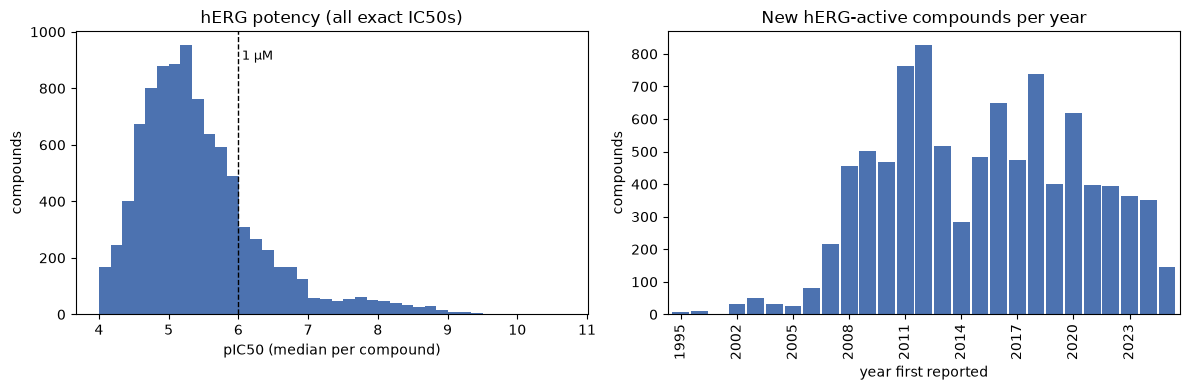

In [14]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.hist(per_cpd["pIC50"], bins=40, color="#4C72B0")
a1.axvline(6, ls="--", c="k", lw=1)
a1.set(xlabel="pIC50 (median per compound)", ylabel="compounds",
       title="hERG potency" + (f" (IC50 < {IC50_CUTOFF_NM / 1000:g} µM)" if IC50_CUTOFF_NM else " (all exact IC50s)"))
a1.text(6.05, a1.get_ylim()[1] * 0.9, "1 µM", fontsize=9)

per_cpd["first_year"].dropna().astype(int).value_counts().sort_index().plot(
    ax=a2, kind="bar", color="#4C72B0", width=0.9)
a2.set(xlabel="year first reported", ylabel="compounds", title="New hERG-active compounds per year")
a2.set_xticks(a2.get_xticks()[::3])
plt.tight_layout()

## Most potent hERG blockers

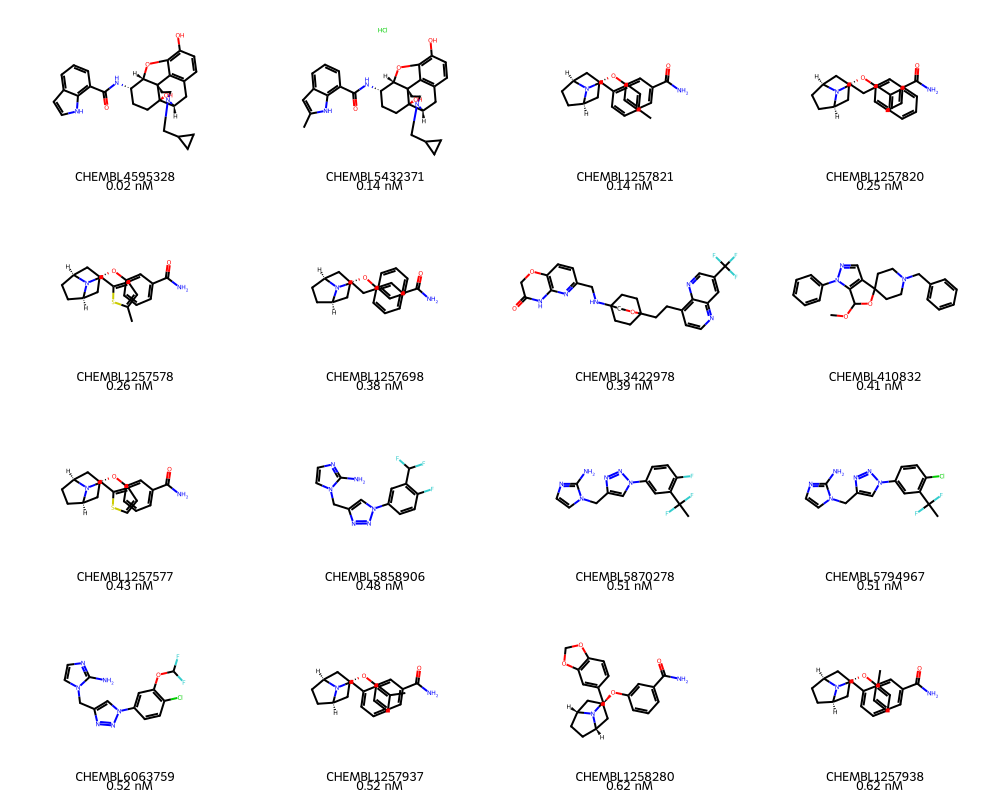

In [15]:
top = per_cpd.head(16)
Draw.MolsToGridImage(
    [Chem.MolFromSmiles(s) for s in top["smiles"]],
    molsPerRow=4, subImgSize=(250, 200),
    legends=[f"{c}\n{(n if isinstance(n, str) else '')[:20]}  {v:.2f} nM" for c, n, v in zip(top["molecule_chembl_id"], top["name"], top["IC50_nM"])],
)

## Physicochemical profile

Descriptor profile of the filtered set (cLogP ≥ 0, MW ≤ 600). hERG blockers are classically
lipophilic bases. With no potency cutoff the set now spans weak (> 10 µM) to very potent
compounds, so these correlations describe the full range of measured hERG IC50s. Note that
compounds reported only as inactive (`>` values) are excluded by the `=` filter, so the
very weak end is still under-represented.

In [16]:
descs = ["cLogP", "MW", "TPSA", "HBD", "aromatic_rings"]

# Spearman correlation of each descriptor with potency
rho = per_cpd[descs + ["pIC50"]].corr("spearman")["pIC50"].drop("pIC50").round(2)

# Median descriptor values by potency class
bins = [-np.inf, 5, 6, 7, 8, np.inf]
labels = ["> 10 µM", "1–10 µM", "100 nM–1 µM", "10–100 nM", "< 10 nM"]
per_cpd["potency_class"] = pd.cut(per_cpd["pIC50"], bins=bins, labels=labels, include_lowest=True)
by_class = per_cpd.groupby("potency_class", observed=True).agg(
    n=("pIC50", "size"), **{d: (d, "median") for d in descs},
    basic_amine_pct=("basic_amine", lambda x: 100 * x.mean()),
).round(1)
by_class.loc["Spearman ρ vs pIC50"] = [np.nan, *rho[descs], np.nan]
by_class

,n,cLogP,MW,TPSA,HBD,aromatic_rings,basic_amine_pct
potency_class,,,,,,,
> 10 µM,3162.0,3.50,436.50,83.30,1.00,3.00,67.9
1–10 µM,4327.0,4.00,433.50,70.80,1.00,3.00,77.5
100 nM–1 µM,1263.0,4.40,445.50,63.20,1.00,3.00,78.8
10–100 nM,331.0,4.40,441.60,60.00,1.00,3.00,65.9
< 10 nM,217.0,3.70,422.60,68.40,1.00,3.00,74.7
Spearman ρ vs pIC50,NaN,0.27,0.03,-0.23,-0.17,0.05,NaN


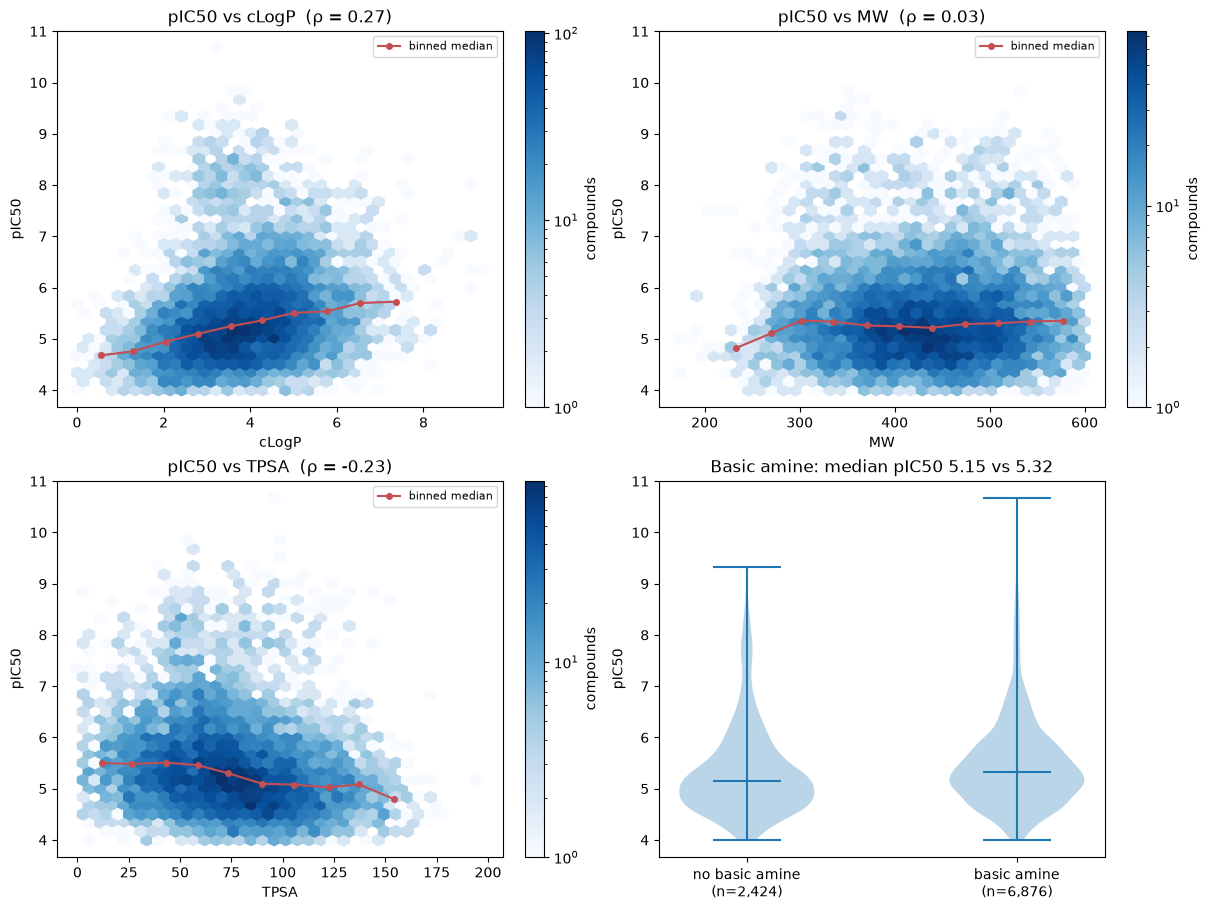

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")

for ax, d in zip(axes.flat[:3], ["cLogP", "MW", "TPSA"]):
    hb = ax.hexbin(per_cpd[d], per_cpd["pIC50"], gridsize=35, mincnt=1, bins="log", cmap="Blues")
    med = per_cpd.groupby(pd.cut(per_cpd[d], 12), observed=True).agg(
        x=(d, "median"), y=("pIC50", "median"), n=("pIC50", "size"))
    med = med[med["n"] >= 20]                  # skip sparse bins at the extremes
    ax.plot(med["x"], med["y"], "o-", c="#C44E52", ms=4, lw=1.5, label="binned median")
    ax.set(xlabel=d, ylabel="pIC50", title=f"pIC50 vs {d}  (ρ = {rho[d]:.2f})")
    ax.legend(loc="upper right", fontsize=8)
    fig.colorbar(hb, ax=ax, label="compounds")

ax = axes.flat[3]
groups = [per_cpd.loc[per_cpd["basic_amine"] == b, "pIC50"] for b in (False, True)]
ax.violinplot(groups, showmedians=True)
ax.set_xticks([1, 2], [f"no basic amine\n(n={len(groups[0]):,})", f"basic amine\n(n={len(groups[1]):,})"])
ax.set(ylabel="pIC50", title=f"Basic amine: median pIC50 {groups[0].median():.2f} vs {groups[1].median():.2f}")
plt.show()

### Carboxylic acids

Acids are generally expected to weaken hERG binding: at physiological pH the carboxylate
disfavours the cation–π and hydrophobic interactions in the pore. Compare potency of compounds with and
without a carboxylic acid, neutral or ionised, matched with the SMARTS `[CX3](=O)[O-,OX2H1]`.

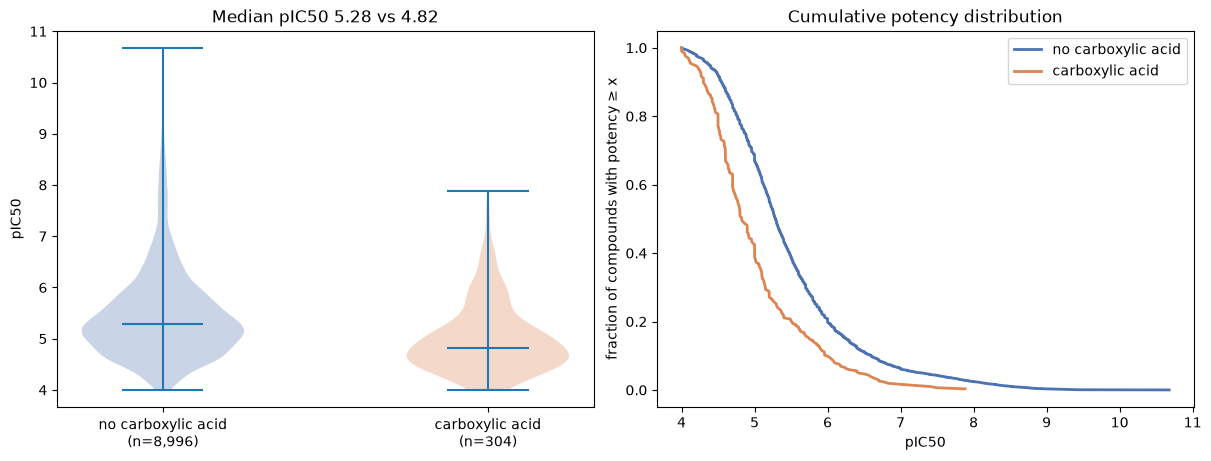

,n,median_pIC50,pct_below_1uM,pct_below_100nM,median_cLogP,pct_basic_amine
carboxylic acid,304,4.82,9.87,1.64,4.70,77.30
no carboxylic acid,8996,5.28,20.84,6.38,3.83,73.82


In [18]:
has_acid = per_cpd["carboxylic_acid"]
acid, no_acid = per_cpd.loc[has_acid, "pIC50"], per_cpd.loc[~has_acid, "pIC50"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

parts = a1.violinplot([no_acid, acid], showmedians=True)
for body, col in zip(parts["bodies"], ["#4C72B0", "#DD8452"]):
    body.set_facecolor(col)
a1.set_xticks([1, 2], [f"no carboxylic acid\n(n={len(no_acid):,})", f"carboxylic acid\n(n={len(acid):,})"])
a1.set(ylabel="pIC50", title=f"Median pIC50 {no_acid.median():.2f} vs {acid.median():.2f}")

# Cumulative distributions: the fraction of each group at or above a given potency
for vals, col, lab in [(no_acid, "#4C72B0", "no carboxylic acid"), (acid, "#DD8452", "carboxylic acid")]:
    x = np.sort(vals)
    a2.plot(x, 1 - np.arange(len(x)) / len(x), c=col, lw=2, label=lab)
a2.set(xlabel="pIC50", ylabel="fraction of compounds with potency ≥ x",
       title="Cumulative potency distribution")
a2.legend()
plt.show()

summary = per_cpd.groupby(has_acid.map({True: "carboxylic acid", False: "no carboxylic acid"})).agg(
    n=("pIC50", "size"),
    median_pIC50=("pIC50", "median"),
    pct_below_1uM=("pIC50", lambda x: 100 * (x >= 6).mean()),
    pct_below_100nM=("pIC50", lambda x: 100 * (x >= 7).mean()),
    median_cLogP=("cLogP", "median"),
    pct_basic_amine=("basic_amine", lambda x: 100 * x.mean()),
).round(2)
summary.index.name = None
summary

41% of compounds are lipophilic bases (basic amine and cLogP > 3.7)


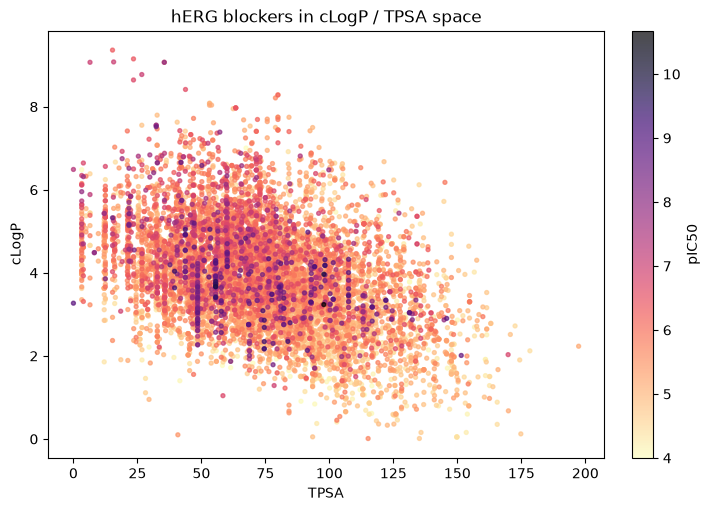

In [19]:
# Where do the filtered compounds sit in cLogP / TPSA space, coloured by potency?
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
order = per_cpd.sort_values("pIC50")          # draw most potent on top
sc = ax.scatter(order["TPSA"], order["cLogP"], c=order["pIC50"], cmap="magma_r", s=8, alpha=0.7)
fig.colorbar(sc, ax=ax, label="pIC50")
ax.set(xlabel="TPSA", ylabel="cLogP", title="hERG blockers in cLogP / TPSA space")
share = (per_cpd["basic_amine"] & (per_cpd["cLogP"] > 3.7)).mean()
print(f"{share:.0%} of compounds are lipophilic bases (basic amine and cLogP > 3.7)")

## Approved and clinical drugs in the set

In [20]:
named = per_cpd[per_cpd["name"].notna()]
phase = pd.DataFrame.from_records(
    new_client.molecule.filter(molecule_chembl_id__in=list(named["molecule_chembl_id"]))
    .only(["molecule_chembl_id", "max_phase"])
)
phase["max_phase"] = pd.to_numeric(phase["max_phase"], errors="coerce")
drugs = named.merge(phase, on="molecule_chembl_id").query("max_phase >= 4")
print(f"{len(drugs)} approved drugs with hERG IC50 data")
drugs[["molecule_chembl_id", "name", "IC50_nM", "n", "cLogP", "basic_amine"]].head(25).round(1)

179 approved drugs with hERG IC50 data


,molecule_chembl_id,name,IC50_nM,n,cLogP,basic_amine
3,CHEMBL502835,NINTEDANIB,2.6,1,3.6,True
4,CHEMBL296419,ASTEMIZOLE,8.0,25,5.4,True
5,CHEMBL533,IBUTILIDE,10.0,5,4.2,True
6,CHEMBL12713,SERTINDOLE,14.0,15,4.6,True
7,CHEMBL473,DOFETILIDE,14.0,23,2.0,True
10,CHEMBL54,HALOPERIDOL,29.2,16,4.4,True
11,CHEMBL1423,PIMOZIDE,31.7,14,5.9,True
13,CHEMBL1108,DROPERIDOL,32.4,9,3.7,True
14,CHEMBL841,LOPERAMIDE,33.0,1,5.1,True
16,CHEMBL71752,VINPOCETINE,39.0,1,4.1,True


## Save

In [21]:
stem = f"herg_ic50_lt{IC50_CUTOFF_NM}nM" if IC50_CUTOFF_NM else "herg_ic50_exact"
df.to_csv(f"{stem}_raw.csv", index=False)
per_cpd.to_csv(f"{stem}_per_compound.csv", index=False)
print(f"wrote {stem}_raw.csv and {stem}_per_compound.csv")

wrote herg_ic50_exact_raw.csv and herg_ic50_exact_per_compound.csv
